# K-vizinhos mais próximos (k-NN)

**Francisco A. Rodrigues**  
Universidade de São Paulo, São Carlos, Brasil  
<https://sites.icmc.usp.br/francisco>  

<hr>

Vamos estudar o método dos **k-vizinhos mais próximos**, conhecido como **k-NN** (*k-nearest neighbors*).

O k-NN é um dos algoritmos mais intuitivos de aprendizado de máquina. A ideia central é simples:

> Para prever a classe ou o valor de uma nova observação, olhamos para as observações mais próximas no conjunto de treinamento.

Apesar de simples, o método é muito útil para introduzir conceitos fundamentais de ciência de dados, como distância, normalização, validação cruzada, escolha de hiperparâmetros, classificação e regressão.


#### **Algoritmo**

Suponha que temos uma nova observação e queremos prever sua classe. O k-NN realiza os seguintes passos:

1. calcula a distância entre a nova observação e todas as observações do conjunto de treinamento;
2. identifica os $k$ vizinhos mais próximos;
3. faz a predição:
   - na **classificação**, usa a classe mais frequente entre os vizinhos;
   - na **regressão**, usa a média dos valores dos vizinhos.

Portanto, o k-NN não aprende uma equação explícita como ocorre na regressão linear. Ele armazena os dados de treinamento e usa esses dados diretamente no momento da predição.

Vamos carregar as bibliotecas necessárias.


In [ ]:
# Importa a biblioteca NumPy, utilizada para operações numéricas e manipulação de vetores e matrizes.
import numpy as np

# Importa a biblioteca Pandas, utilizada para manipulação e análise de dados organizados em tabelas.
import pandas as pd

# Importa o módulo pyplot do Matplotlib para criação de gráficos.
import matplotlib.pyplot as plt

# Importa funções para gerar conjuntos de dados artificiais:
# - make_classification: dados para problemas de classificação;
# - make_moons: dados não linearmente separáveis em formato de luas;
# - make_regression: dados para problemas de regressão.
from sklearn.datasets import make_classification, make_moons, make_regression

# Importa conjuntos de dados reais disponíveis no scikit-learn:
# - Iris: classificação de espécies de flores;
# - Breast Cancer: classificação de tumores;
# - Diabetes: problema de regressão.
from sklearn.datasets import load_iris, load_breast_cancer, load_diabetes

from sklearn.model_selection import train_test_split

# Importa o StandardScaler, utilizado para padronizar os atributos,
# deixando-os com média zero e desvio-padrão igual a um.
from sklearn.preprocessing import StandardScaler

# Importa os modelos baseados no método dos k-vizinhos mais próximos:
# - KNeighborsClassifier: utilizado em problemas de classificação;
# - KNeighborsRegressor: utilizado em problemas de regressão.
from sklearn.neighbors import (
    KNeighborsClassifier,
    KNeighborsRegressor
)

# Importa métricas para avaliar modelos de classificação e regressão.
from sklearn.metrics import (
    # Proporção de classificações corretas.
    accuracy_score,

    # Erro quadrático médio para problemas de regressão.
    mean_squared_error,

    # Erro absoluto médio para problemas de regressão.
    mean_absolute_error,
)

# Importa Pipeline, que permite encadear etapas de pré-processamento
# e treinamento em um único objeto.
from sklearn.pipeline import Pipeline

# Define uma semente para os processos aleatórios.
# Isso permite reproduzir os mesmos resultados em diferentes execuções.
RANDOM_STATE = 42

# Define a semente do gerador de números aleatórios do NumPy.
np.random.seed(RANDOM_STATE)

### **1 - Implementação manual do k-NN para classificação**

Antes de usar o `scikit-learn`, vamos implementar uma versão simples do k-NN para entender a lógica do método.

Considere pontos em duas dimensões. Cada ponto pertence a uma das classes: 0 ou 1. Queremos classificar um novo ponto com base nos seus vizinhos mais próximos.


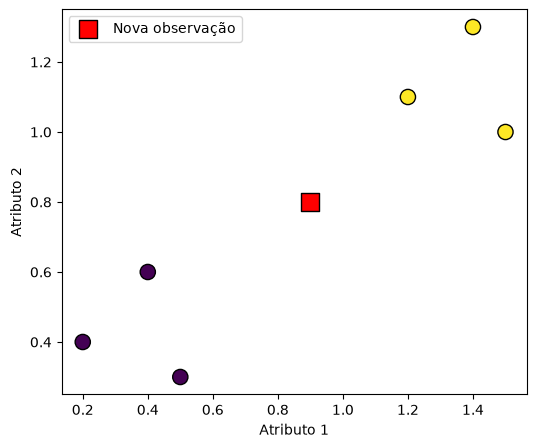

In [ ]:
# Conjunto de treinamento simples
X_train_manual = np.array([
    [0.2, 0.4],
    [0.4, 0.6],
    [0.5, 0.3],
    [1.2, 1.1],
    [1.4, 1.3],
    [1.5, 1.0]
])
y_train_manual = np.array([0, 0, 0, 1, 1, 1])

# Novo ponto a ser classificado
x_new = np.array([0.9, 0.8])

plt.figure(figsize=(6, 5))
plt.scatter(X_train_manual[:, 0], X_train_manual[:, 1], c=y_train_manual, s=120, edgecolor='black')
plt.scatter(x_new[0], x_new[1], marker='s', s=150, c='red', edgecolor='black', label='Nova observação')
plt.xlabel('Atributo 1')
plt.ylabel('Atributo 2')
plt.legend()
plt.grid(False)
plt.show()

In [ ]:
def knn_classificacao_manual(X_train, y_train, x_new, k=3):
    """
    Implementação simples do k-NN para classificação.
    Parâmetros
    ----------
    X_train : array com os atributos de treinamento
    y_train : array com as classes de treinamento
    x_new : observação que queremos classificar
    k : número de vizinhos
    Retorna
    -------
    classe_predita : classe mais frequente entre os k vizinhos
    vizinhos : índices dos k vizinhos mais próximos
    distancias : distâncias de x_new até todos os pontos de treinamento
    """
    # Calcula a distância euclidiana entre x_new e cada ponto de treinamento
    distancias = np.sqrt(np.sum((X_train - x_new) ** 2, axis=1))

    # Ordena os pontos pela distância
    vizinhos = np.argsort(distancias)[:k]

    # Classes dos k vizinhos
    classes_vizinhos = y_train[vizinhos]

    # Classe mais frequente
    valores, contagens = np.unique(classes_vizinhos, return_counts=True)
    classe_predita = valores[np.argmax(contagens)]

    return classe_predita, vizinhos, distancias

# Executa o classificador manual para a nova observação x_new,
# considerando os k vizinhos mais próximos.
classe_predita, vizinhos, distancias = knn_classificacao_manual(
    X_train_manual, y_train_manual, x_new, k=3)

# Exibe a distância entre a nova observação e cada ponto do conjunto de treinamento.
print('Distâncias até a nova observação:')
for i, d in enumerate(distancias):
    print(f'Ponto {i}: distância = {d:.3f}, classe = {y_train_manual[i]}')

print('\nÍndices dos vizinhos mais próximos:', vizinhos)
print('Classe predita:', classe_predita)

Distâncias até a nova observação:
Ponto 0: distância = 0.806, classe = 0
Ponto 1: distância = 0.539, classe = 0
Ponto 2: distância = 0.640, classe = 0
Ponto 3: distância = 0.424, classe = 1
Ponto 4: distância = 0.707, classe = 1
Ponto 5: distância = 0.632, classe = 1

Índices dos vizinhos mais próximos: [3 1 5]
Classe predita: 1


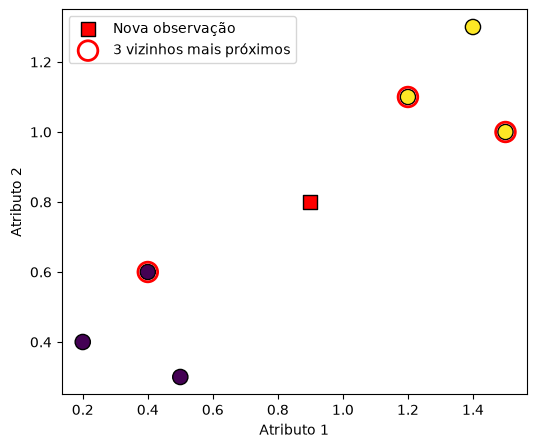

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(X_train_manual[:, 0], X_train_manual[:, 1], c=y_train_manual, s=120, edgecolor='black')
plt.scatter(x_new[0], x_new[1], marker='s', s=100, c='red', edgecolor='black', label='Nova observação')
plt.scatter(X_train_manual[vizinhos, 0], X_train_manual[vizinhos, 1],
            facecolors='none', edgecolors='red', s=200, linewidths=2, label='3 vizinhos mais próximos')
plt.xlabel('Atributo 1')
plt.ylabel('Atributo 2')
plt.legend()
plt.grid(False)
plt.show()

### Normalização

O k-NN usa distâncias. Por isso, variáveis com escala maior podem dominar o cálculo da distância.

Por exemplo, suponha que temos duas variáveis:

- idade, variando entre 18 e 80;
- renda, variando entre 1000 e 30000.

A variável renda terá uma influência muito maior na distância euclidiana apenas porque está em uma escala maior.

Para evitar esse problema, normalmente usamos **padronização**, transformando cada variável para ter média 0 e desvio padrão 1:

$$
z = \frac{x - \mu}{\sigma}.
$$

No `scikit-learn`, isso pode ser feito com `StandardScaler`.


## **2 - k-NN para classificação**

Vamos gerar um conjunto de dados artificial em duas dimensões. Como os dados têm apenas dois atributos, podemos visualizar a região de decisão do classificador.


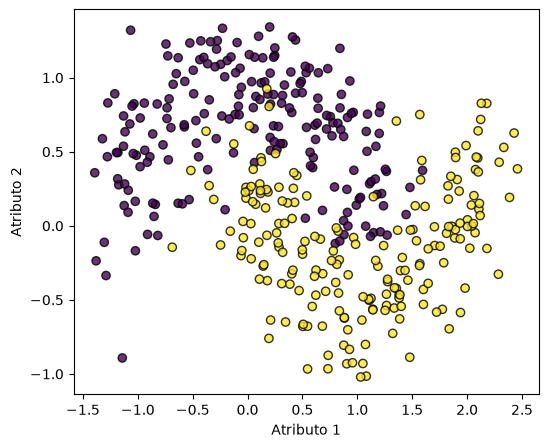

In [ ]:
# Gera um conjunto de dados artificial para classificação binária.
X, y = make_moons(n_samples=400, noise=0.25, random_state=RANDOM_STATE)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='black', alpha=0.8)
plt.xlabel('Atributo 1')
plt.ylabel('Atributo 2')
plt.grid(False)
plt.show()

Para treinar o classificador, precisamos definir o conjunto de teste e treinamento.

In [ ]:
# Divide o conjunto de dados em subconjuntos de treinamento e teste.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,stratify=y, random_state=RANDOM_STATE)

Vamos normalizar os dados, de modo a evitar o efeito da escala dos atributos.

In [ ]:
# Importa o StandardScaler, utilizado para padronizar os atributos.
from sklearn.preprocessing import StandardScaler

# Cria o padronizador e calcula, usando apenas o conjunto de treinamento, a média e o desvio-padrão de cada atributo.
scaler = StandardScaler().fit(X_train)

# Padroniza os atributos do conjunto de treinamento.
X_train = scaler.transform(X_train)

# Padroniza o conjunto de teste utilizando as mesmas médias
# e os mesmos desvios-padrão calculados no conjunto de treinamento.
X_test = scaler.transform(X_test)

Para realizar a classificação, utilizaremos a biblioteca `scikit-learn` (https://scikit-learn.org). O método também pode ser implementado com métricas de distância diferentes da Euclidiana, como as apresentadas na documentação: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.DistanceMetric.html

Inicialmente, ajustaremos o modelo utilizando o método *hold-out* para dividir os dados em conjuntos de treinamento e teste. Nesse procedimento, uma fração (p) das observações é destinada ao conjunto de teste, enquanto a fração (1-p) é utilizada para o treinamento do modelo.

A seguir, realizaremos a classificação utilizando o método dos (k)-vizinhos mais próximos.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
k = 41 # numero de vizinhos

# ajusta o modelo k-vizinhos
model = KNeighborsClassifier(n_neighbors=k, metric = 'euclidean')
model.fit(X_train,y_train)

# faz a predição no conjunto de teste
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

# Calcula a proporção de observações do conjunto de teste
# cujas classes foram previstas corretamente.
score = accuracy_score(y_pred, y_test)
print('Accuracia para k=', k,':',score)

Accuracia para k= 41 : 0.9375


O valor da acurácia depende do número de vizinhos $k$. Podemos selecionar o melhor valor de $k$ vamos usar validação cruzada, que aprenderemos nas próximas aulas deste curso.

Podemos mostrar a região de decisão.

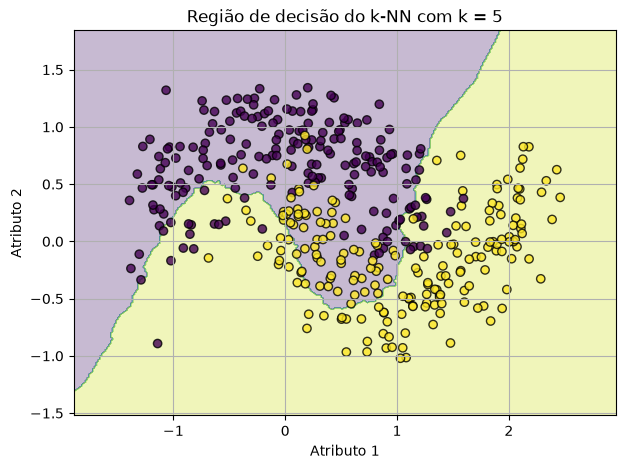

In [ ]:
def plot_decision_boundary(model, X, y, title='Região de decisão'):
    """
    Função auxiliar para visualizar a região de decisão em problemas com dois atributos.
    """
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='black', alpha=0.8)
    plt.xlabel('Atributo 1')
    plt.ylabel('Atributo 2')
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_decision_boundary(model, X, y, title='Região de decisão do k-NN com k = 5')


Variando k.

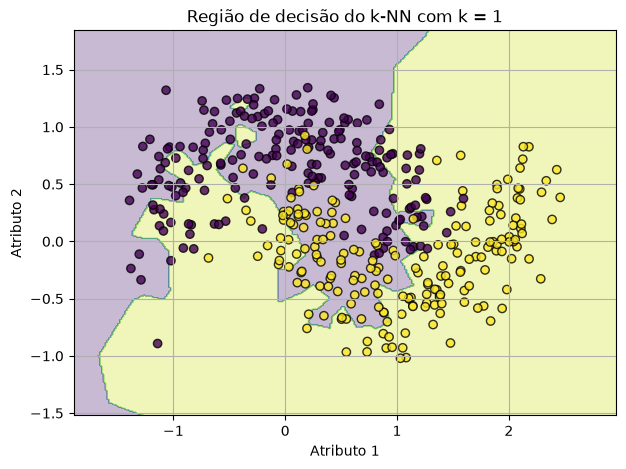

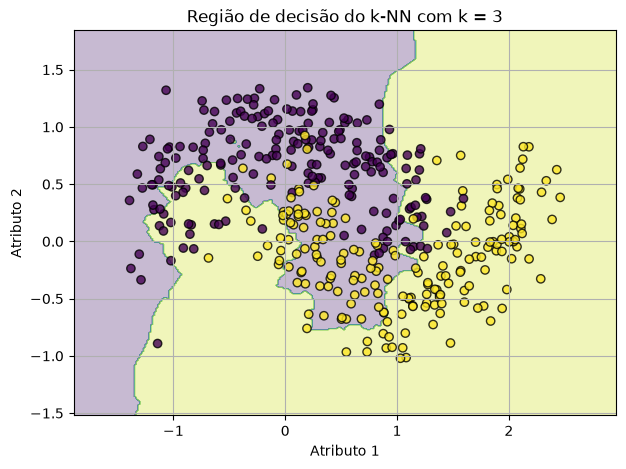

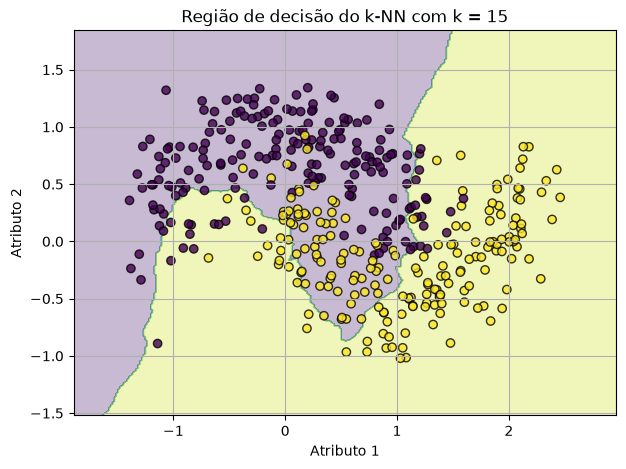

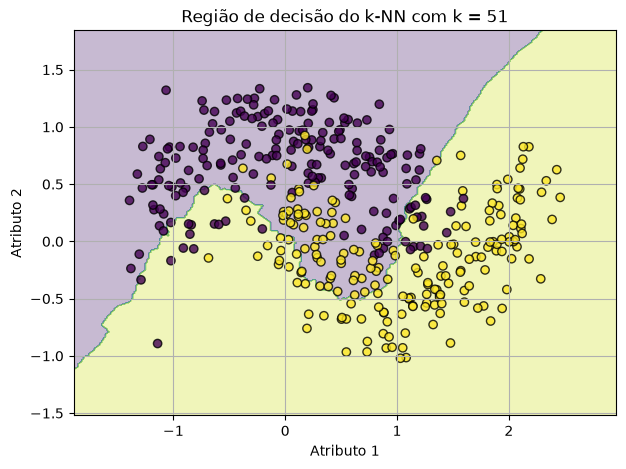

In [ ]:
for k in [1, 3, 15, 51]:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(X_train, y_train)
    plot_decision_boundary(model, X, y, title=f'Região de decisão do k-NN com k = {k}')

## **Classificação com dados reais**

Agora vamos usar uma base real bastante conhecida: a base **Iris**.

Ela contém medidas de flores de três espécies diferentes:

- *Iris setosa*;
- *Iris versicolor*;
- *Iris virginica*.

O objetivo é classificar a espécie da flor com base em medidas como comprimento e largura da sépala e da pétala.


In [ ]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# se for usar o Colab, descomente abaixo
#from google.colab import drive
# Monta o Google Drive na pasta '/content/drive' deste ambiente do Colab.
# Depois deste comando, os arquivos do seu Drive ficam acessíveis normalmente,
# como se fossem arquivos locais dentro de '/content/drive/MyDrive/...'
#drive.mount('/content/drive/')
#caminho_drive = '/content/drive/MyDrive/data/Vehicle.csv'
#data = pd.read_csv(caminho_drive, header=0)

# for ler do disco local, descomente abaixo
#data = pd.read_csv('data/vertebralcolumn-3C.csv', header=(0))
#data = pd.read_csv('data/winequality-red.csv', header=(0))
#data = pd.read_csv('data/Vehicle.csv', header=(0))
data = pd.read_csv(r'C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\iris.csv', header=(0))



Matriz de atributos: Número de linhas: 150  colunas:  5


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


Convertemos os dados para o formato Numpy para facilitar a sua manipulação.

In [ ]:
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

Para treinar o classificador, precisamos definir o conjunto de teste e treinamento.

In [ ]:
from sklearn.model_selection import train_test_split

p = 0.7 

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = p, random_state = 42, stratify = y)

Vamos normalizar os dados, de modo a evitar o efeito da escala dos atributos.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

A partir desse conjunto de dados, podemos realizar a classificação.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

k = 11 # numero de vizinhos

# ajusta o modelo k-vizinhos
model = KNeighborsClassifier(n_neighbors=k, metric = 'euclidean')
model.fit(X_train,y_train)

# faz a predição no conjunto de teste
y_pred = model.predict(X_test)

O erro na classificação pode ser quantificado pela medida de acurácia.

In [ ]:
from sklearn.metrics import accuracy_score

score = accuracy_score(y_pred, y_test)
print('Accuracia para k=', k,':', score)

Accuracia para k= 11 : 0.9555555555555556


# **2 - k-NN para regressão**

Até agora, usamos o k-NN para classificação. No entanto, o mesmo princípio pode ser usado para regressão.

Na regressão, queremos prever um valor numérico. O k-NN faz isso calculando a média dos valores dos vizinhos mais próximos.

Se os $k$ vizinhos mais próximos de uma nova observação têm respostas:

$$
y_1, y_2, \ldots, y_k,
$$

então a predição é:

$$
\hat{y} = \frac{1}{k}\sum_{i=1}^{k} y_i.
$$

Também é possível usar uma média ponderada, em que vizinhos mais próximos recebem maior peso.


### Regressão com dados artificiais

Vamos criar uma função não linear com ruído. O objetivo será prever $y$ a partir de $x$ usando k-NN regressão.


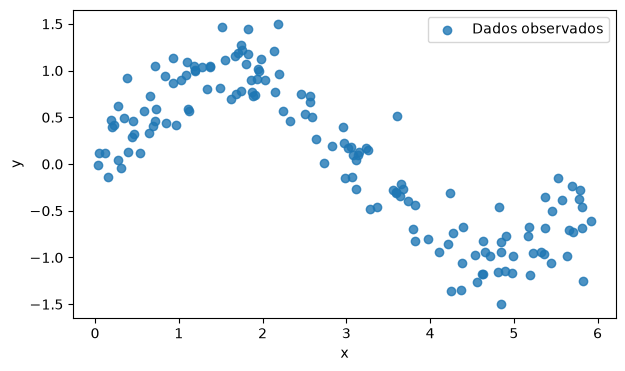

In [ ]:
rng = np.random.RandomState(RANDOM_STATE)

# Gera 150 valores aleatórios entre 0 e 6.
# O formato (150, 1) indica:
# - 150 observações;
# - um único atributo para cada observação.
# np.sort organiza os valores em ordem crescente, facilitando posteriormente a visualização da curva estimada.
X_reg = np.sort(6 * rng.rand(150, 1),axis=0)

# Gera a variável resposta a partir da função seno.
# np.sin(X_reg) calcula o seno de cada valor de entrada.
# ravel() transforma o resultado de uma matriz (150, 1) em um vetor unidimensional com 150 elementos.
# O termo 0.25 * rng.randn(150) adiciona um erro aleatório com distribuição normal, média zero e desvio-padrão igual a 0.25.
y_reg = (np.sin(X_reg).ravel()+ 0.25 * rng.randn(150))

# Cria uma figura
plt.figure(figsize=(7, 4))

# Constrói um gráfico de dispersão com os dados gerados.
# alpha=0.8 define uma pequena transparência nos pontos.
# label define o texto que será apresentado na legenda.
plt.scatter(X_reg,y_reg,alpha=0.8,label='Dados observados')

# Define o rótulo do eixo horizontal.
plt.xlabel('x')

# Define o rótulo do eixo vertical.
plt.ylabel('y')

# Exibe a legenda do gráfico.
plt.legend()

# Remove as linhas de grade.
plt.grid(False)

# Exibe o gráfico.
plt.show()

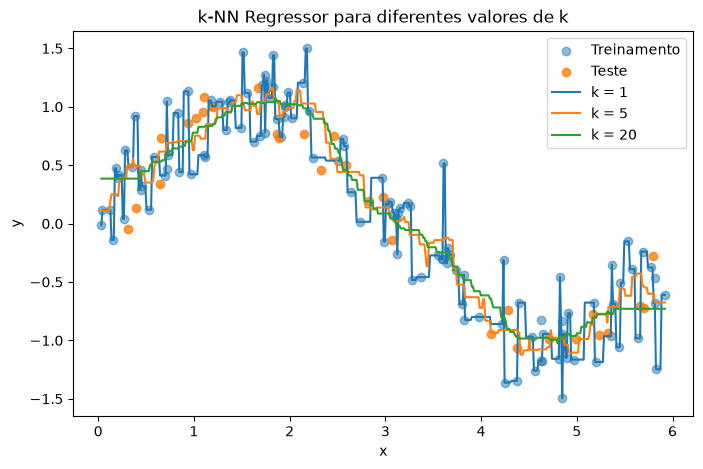

In [ ]:
# Divide os dados em conjuntos de treinamento e teste.
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg,test_size=0.20,random_state=RANDOM_STATE)
# Cria uma grade com 500 valores igualmente espaçados entre o menor e o maior valor observado em X_reg.
x_grid = np.linspace(X_reg.min(), X_reg.max(), 500).reshape(-1, 1)

# Cria uma figura
plt.figure(figsize=(8, 5))
# Exibe os dados utilizados no treinamento.
plt.scatter(X_train, y_train, alpha=0.5, label='Treinamento')
# Exibe os dados reservados para o teste.
plt.scatter(X_test, y_test, alpha=0.8, label='Teste')

# Ajusta modelos k-NN de regressão usando diferentes valores de k.
for k in [1, 5, 20]:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    y_grid = model.predict(x_grid)
    plt.plot(x_grid, y_grid, label=f'k = {k}')

plt.xlabel('x')
plt.ylabel('y')
plt.title('k-NN Regressor para diferentes valores de k')
plt.legend()
plt.grid(False)
plt.show()

Observe que:

- com $k=1$, o modelo fica muito irregular, acompanhando fortemente os dados de treinamento;
- com $k=5$, o modelo fica mais suave;
- com $k=20$, o modelo pode ficar suave demais, perdendo detalhes da função.

Esse comportamento é análogo ao caso de classificação. Vamos analisar como o RMSE muda de acordo com o valor de k. Essa não é a melhor maneira de escolhermos o valor de k. Em aulas futuras, vamos aprender sobre validação cruzada, que é o método adequado para fazer essa escolha.


Melhor k no conjunto de teste: 15
Menor RMSE: 0.19632938673824335


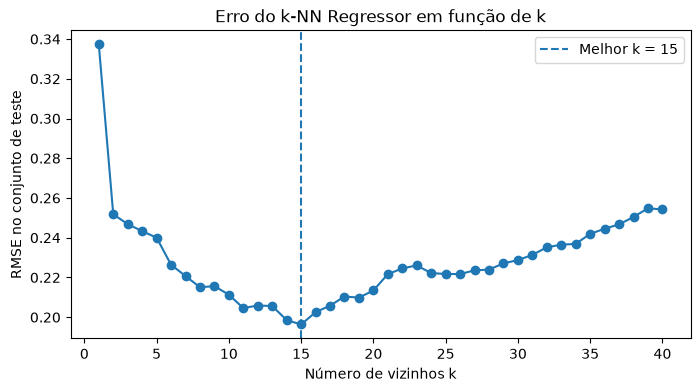

In [ ]:
# Importa a função que calcula a raiz do erro quadrático médio.
from sklearn.metrics import root_mean_squared_error

# Define os valores de k que serão avaliados, de 1 até 40.
valores_k = range(1, 41)
rmse_teste = [] # Lista que armazenará o RMSE obtido para cada valor de k.

# Avalia o desempenho do regressor para diferentes números de vizinhos.
for k in valores_k:
    # Cria o modelo de regressão k-NN considerando k vizinhos.
    model = KNeighborsRegressor(n_neighbors=k)
    # Ajusta o modelo utilizando os dados de treinamento.
    model.fit(X_train, y_train)
    # Faz previsões para as observações do conjunto de teste.
    y_pred = model.predict(X_test)
    # Calcula a raiz do erro quadrático médio entre os valores reais e os valores previstos.
    rmse = root_mean_squared_error(y_test, y_pred)
    # Armazena o erro correspondente ao valor atual de k.
    rmse_teste.append(rmse)

# np.argmin retorna a posição do menor RMSE na lista.
indice_melhor = np.argmin(rmse_teste)

# Recupera o valor de k associado ao menor erro.
melhor_k = list(valores_k)[indice_melhor]

print('Melhor k no conjunto de teste:', melhor_k)
print('Menor RMSE:', min(rmse_teste))

plt.figure(figsize=(8, 4))
plt.plot(list(valores_k), rmse_teste, marker='o')
plt.axvline(melhor_k, linestyle='--', label=f'Melhor k = {melhor_k}')
plt.xlabel('Número de vizinhos k')
plt.ylabel('RMSE no conjunto de teste')
plt.title('Erro do k-NN Regressor em função de k')
plt.legend()
plt.grid(False)
plt.show()

### Regressão com dados reais: base Diabetes

Vamos usar a base **Diabetes**, disponível no `scikit-learn`.

Essa base contém variáveis clínicas padronizadas e uma variável resposta que representa uma medida quantitativa da progressão da doença um ano após a coleta dos dados.

O objetivo é prever essa variável resposta a partir das demais variáveis.


In [ ]:
diabetes = load_diabetes(as_frame=True)

X_diabetes = diabetes.data
y_diabetes = diabetes.target

print('Dimensão dos dados:', X_diabetes.shape)
X_diabetes.head()

Dimensão dos dados: (442, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_diabetes, y_diabetes,
    test_size=0.25,
    random_state=RANDOM_STATE
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
k = 21
model = KNeighborsRegressor(n_neighbors=k)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
print(rmse)

54.09795647727801


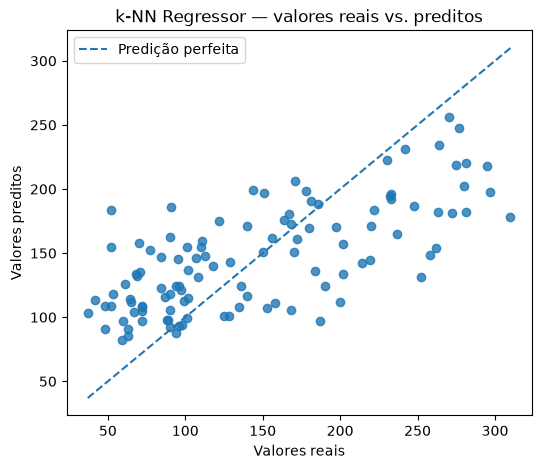

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.8)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', label='Predição perfeita')

plt.xlabel('Valores reais')
plt.ylabel('Valores preditos')
plt.title('k-NN Regressor — valores reais vs. preditos')
plt.legend()
plt.grid(False)
plt.show()

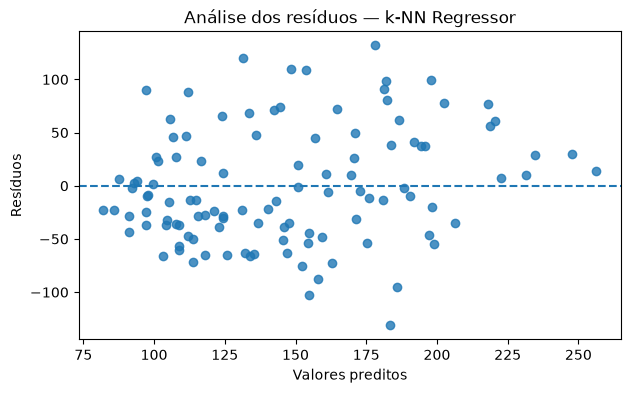

In [ ]:
residuos = y_test - y_pred

plt.figure(figsize=(7, 4))
plt.scatter(y_pred, residuos, alpha=0.8)
plt.axhline(0, linestyle='--')
plt.xlabel('Valores preditos')
plt.ylabel('Resíduos')
plt.title('Análise dos resíduos — k-NN Regressor')
plt.grid(False)
plt.show()

## Exercícios de fixação

1. No exemplo com dados artificiais de classificação, teste os valores $k=1$, $k=3$, $k=7$, $k=15$ e $k=31$. Como a região de decisão muda?

2. Na base Iris, compare o desempenho do k-NN usando distância euclidiana e Manhattan.

3. No exemplo de regressão artificial, aumente o ruído dos dados. O que acontece com o melhor valor de $k$?

4. Substitua o `StandardScaler` por `MinMaxScaler` e compare os resultados.